In [1]:
here::i_am("rna_atac/clustering/02_clustering.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(ArchR))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 21

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘rtracklayer’ was built under R version 4.2.3”

                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | 

In [2]:
args = list()

# Metadata
args$metadata = file.path(io$basedir, 'results/rna_atac/clustering/metadata_celltype_annotated_v2.txt.gz')

# RNA_sce
args$rna_sce = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')

# Archr
args$archr_directory = file.path(io$basedir, 'processed/atac/archR')

# outdir
args$outdir = file.path(io$basedir, 'results/rna_atac/celltype_markers/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

In [3]:
# Load meta
meta = fread(args$metadata) %>% 
    .[genotype=='WT']  # Only WT cells for celltype marker search

## RNA

In [4]:
# load sce
rna.sce <- load_SingleCellExperiment(args$rna_sce, normalise = TRUE, cells = meta$cell)
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

# Convert to Seurat
seurat = as.Seurat(rna.sce)

In [5]:
# Prepare mofa umap
umap.mtx = meta[,c('cell', 'UMAP1', 'UMAP2')] %>% 
    as.data.frame(.) %>% 
    tibble::column_to_rownames('cell') %>%
    as.matrix()
seurat[["umap"]] <- CreateDimReducObject(embeddings = umap.mtx, key = "umap_", assay = DefaultAssay(seurat))

In [6]:
Idents(seurat) = seurat@meta.data$celltype_v2

#### Seurat

In [12]:
eo_d_vs_i = as.data.table(FindMarkers(seurat, ident.1 = "Early_Mes_EOi", ident.2 = "Early_Mes_EOd", verbose = FALSE), keep.rownames = T) %>%
    setnames('rn', 'gene')

In [10]:
seurat

An object of class Seurat 
32285 features across 19740 samples within 1 assay 
Active assay: RNA (32285 features, 0 variable features)
 1 dimensional reduction calculated: umap

In [21]:
seurat_PS = seurat[,seurat$celltype_v2 == 'Primitive_Streak']

In [29]:
seurat_PS = AddModuleScore(
  object = seurat_PS,
  features  = list(test1 = eo_d_vs_i[avg_log2FC > 0.5 & p_val_adj < 0.05, gene],
                  test2 = eo_d_vs_i[avg_log2FC < -0.5 & p_val_adj < 0.05, gene]),
  names = 'Eoi')

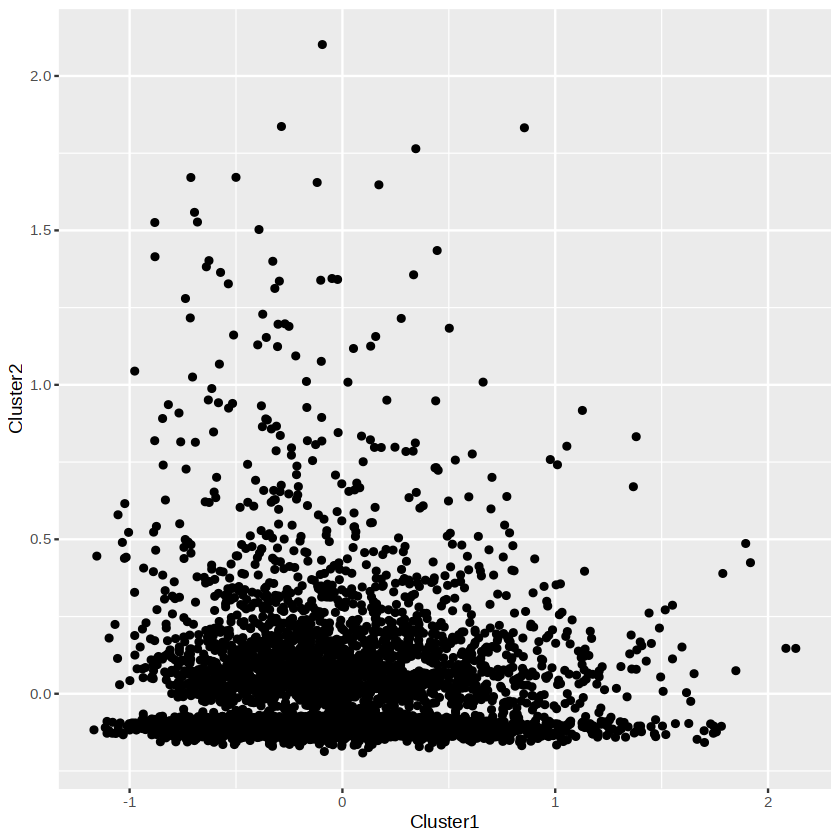

In [34]:
meta_seurat = as.data.table(seurat_PS@meta.data)

ggplot(meta_seurat, aes(Cluster1, Cluster2)) + 
    geom_point()

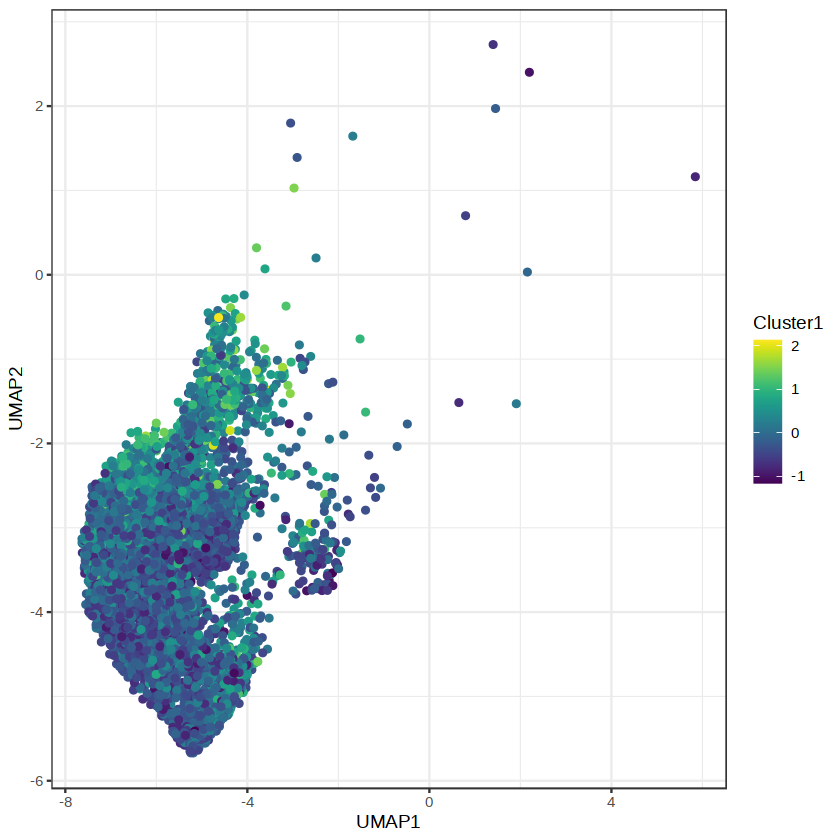

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”


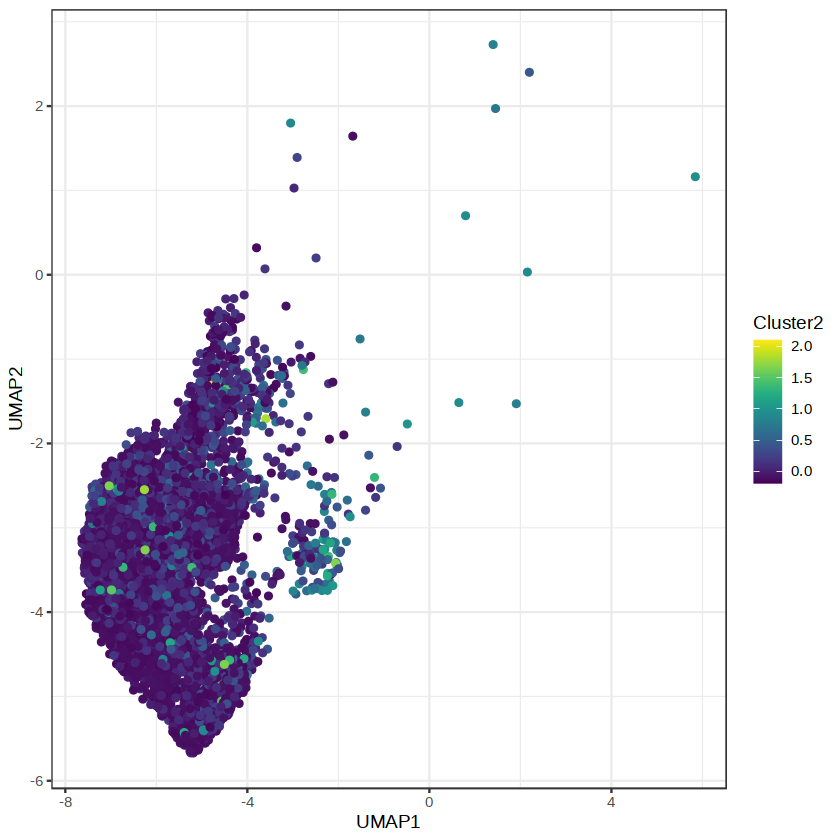

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”


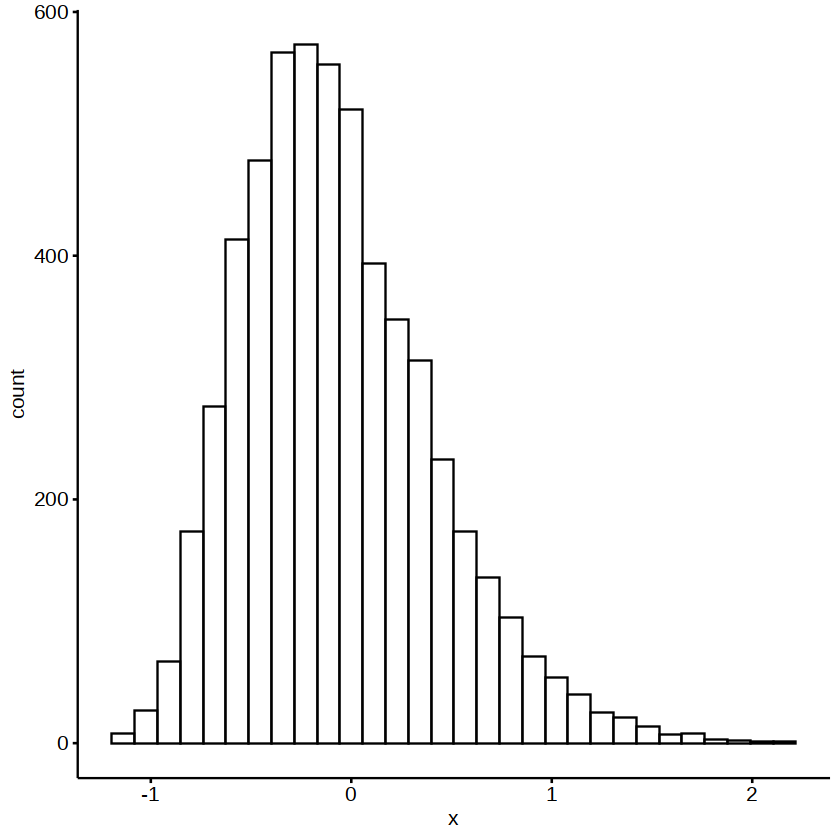

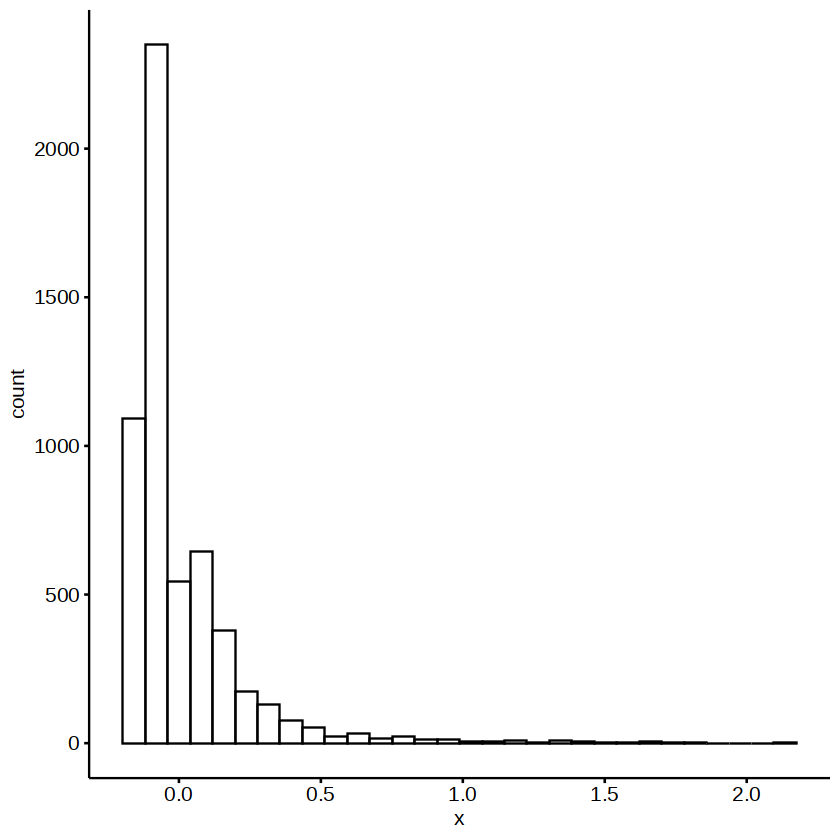

In [33]:
meta_seurat = meta_seurat[order()]
ggplot(meta_seurat, aes(UMAP1, UMAP2, color = Cluster1)) + 
    geom_point() + 
    viridis::scale_color_viridis() + 
    theme_bw()

ggplot(meta_seurat, aes(UMAP1, UMAP2, color = Cluster2)) + 
    geom_point() + 
    viridis::scale_color_viridis() + 
    theme_bw()

gghistogram(meta_seurat$Cluster1)
gghistogram(meta_seurat$Cluster2)